# 05 - Pipeline Visualisation Report

Generate and preview saved visuals for data flow, dataset inventory, labels, weather coverage, feature quality, and model ranking.

## 1. Setup

In [4]:
from pathlib import Path
import sys, json, subprocess
import pandas as pd
from IPython.display import display, Image, HTML


def resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root. Run this notebook from the repo or notebooks folder.')

PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import load_config
from src.pipeline_reporting import configure_pretty_logging, output_dir, save_dataset_inventory, save_dataframe, save_table_image, save_bar_chart

config = load_config(PROJECT_ROOT / 'configs' / 'config.yaml')
paths = config['paths']
processed_dir = PROJECT_ROOT / paths.get('processed_data_dir', 'data/processed')
raw_dir = PROJECT_ROOT / paths.get('raw_data_dir', 'data/raw')
outputs_dir = PROJECT_ROOT / 'outputs'
notebook_out = output_dir('05_visualisation', root=outputs_dir / 'notebook_reports')
log_file = configure_pretty_logging(PROJECT_ROOT / 'logs', '05_visualisation')
print('Project root:', PROJECT_ROOT)
print('Notebook output dir:', notebook_out)
print('Notebook log file:', log_file)

Project root: C:\Code\flight-disruption-prediction
Notebook output dir: C:\Code\flight-disruption-prediction\outputs\notebook_reports\05_visualisation
Notebook log file: C:\Code\flight-disruption-prediction\logs\05_visualisation_20260428_203246.log


## 2. Generate Full Report

In [5]:
cmd = [sys.executable, str(PROJECT_ROOT / 'scripts' / 'generate_pipeline_report.py')]
print('Running:', ' '.join(cmd))
completed = subprocess.run(cmd, cwd=PROJECT_ROOT, text=True, capture_output=True)
print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError('Pipeline report generation failed')
report_dir = PROJECT_ROOT / 'outputs' / 'pipeline_report'
print('Report dir:', report_dir)

Running: c:\Code\.venv311\Scripts\python.exe C:\Code\flight-disruption-prediction\scripts\generate_pipeline_report.py
Pipeline report saved to C:\Code\flight-disruption-prediction\outputs\pipeline_report
             dataset                                                                             path  exists  size_mb       rows  columns                  min_time                  max_time
       adsb_combined        C:\Code\flight-disruption-prediction\data\processed\adsb_combined.parquet    True 45029.80 1296709098       20                1641168000                1656374390
        bts_combined         C:\Code\flight-disruption-prediction\data\processed\bts_combined.parquet    True   163.66    2683015       26 2022-01-01 05:55:00+00:00 2022-06-30 23:59:00+00:00
eurocontrol_combined C:\Code\flight-disruption-prediction\data\processed\eurocontrol_combined.parquet    True   131.20    4339106       12 2022-01-01 00:00:00+00:00 2022-06-30 23:58:15+00:00
 trajectory_features  C:\Code\fl

## 3. Preview Key Visuals


pipeline_data_flow.png


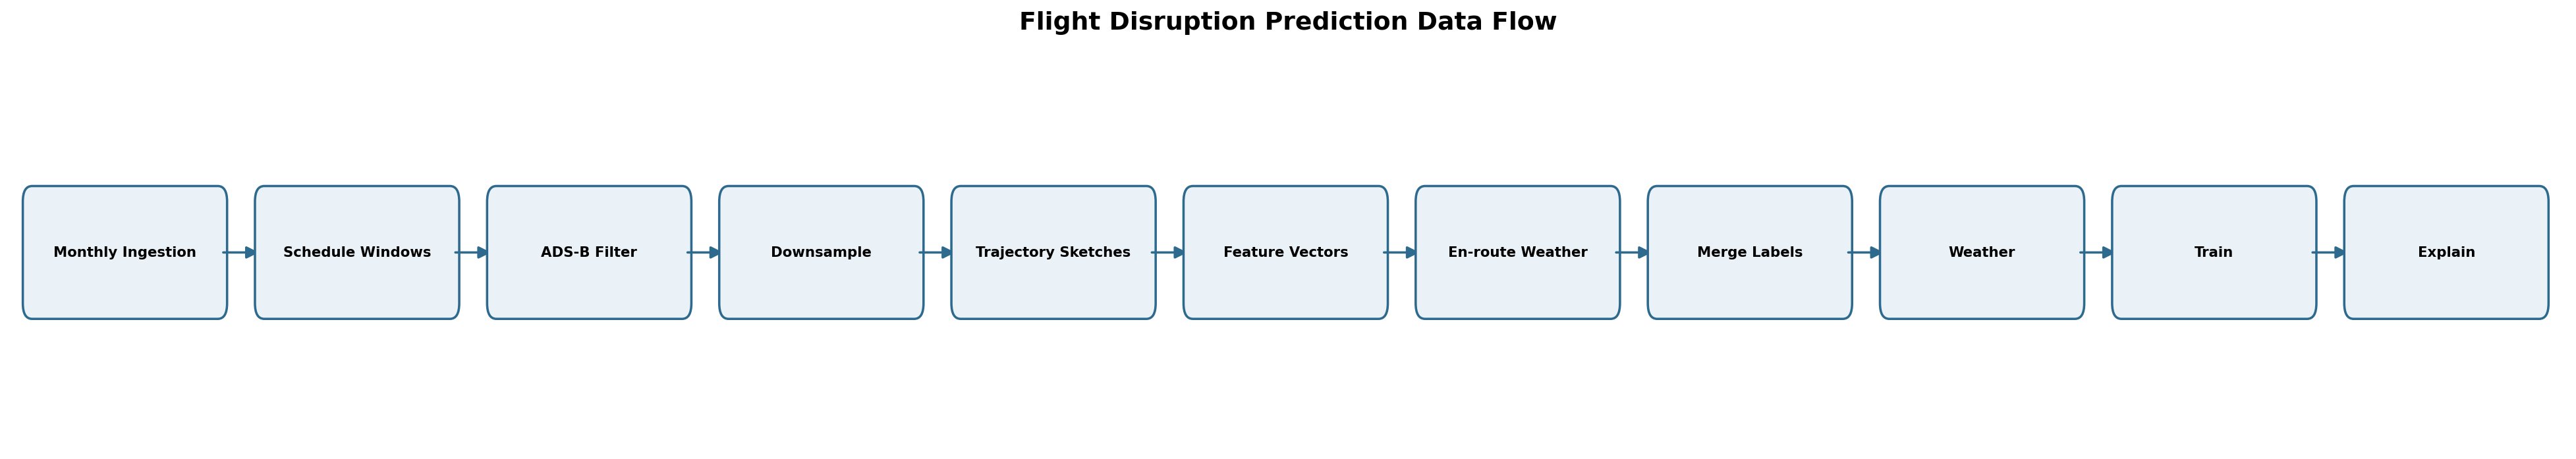


dataset_inventory.png


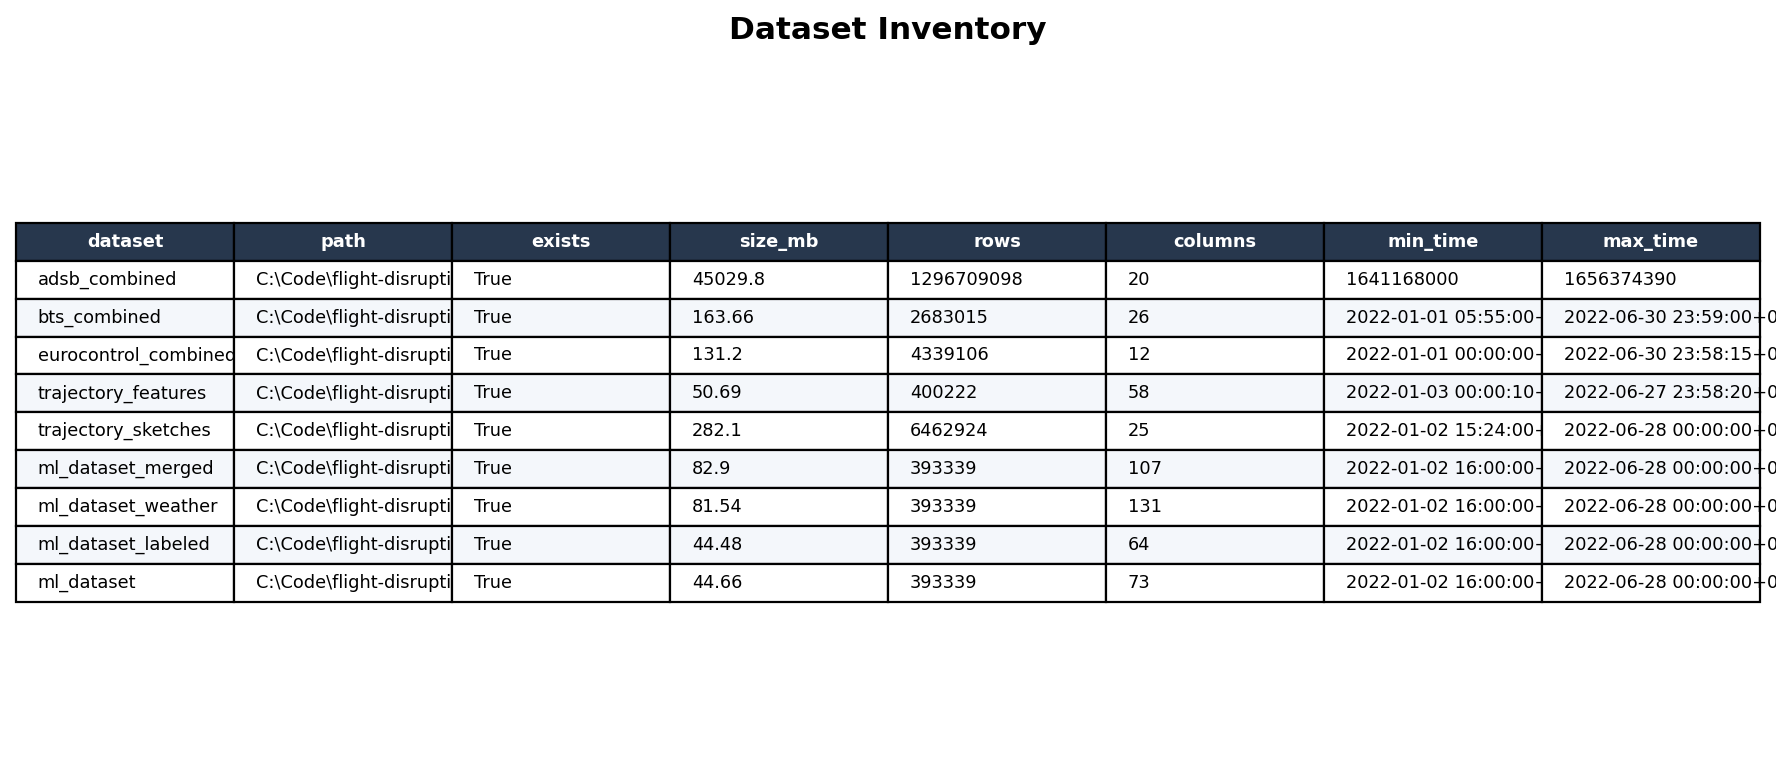


dataset_sizes.png


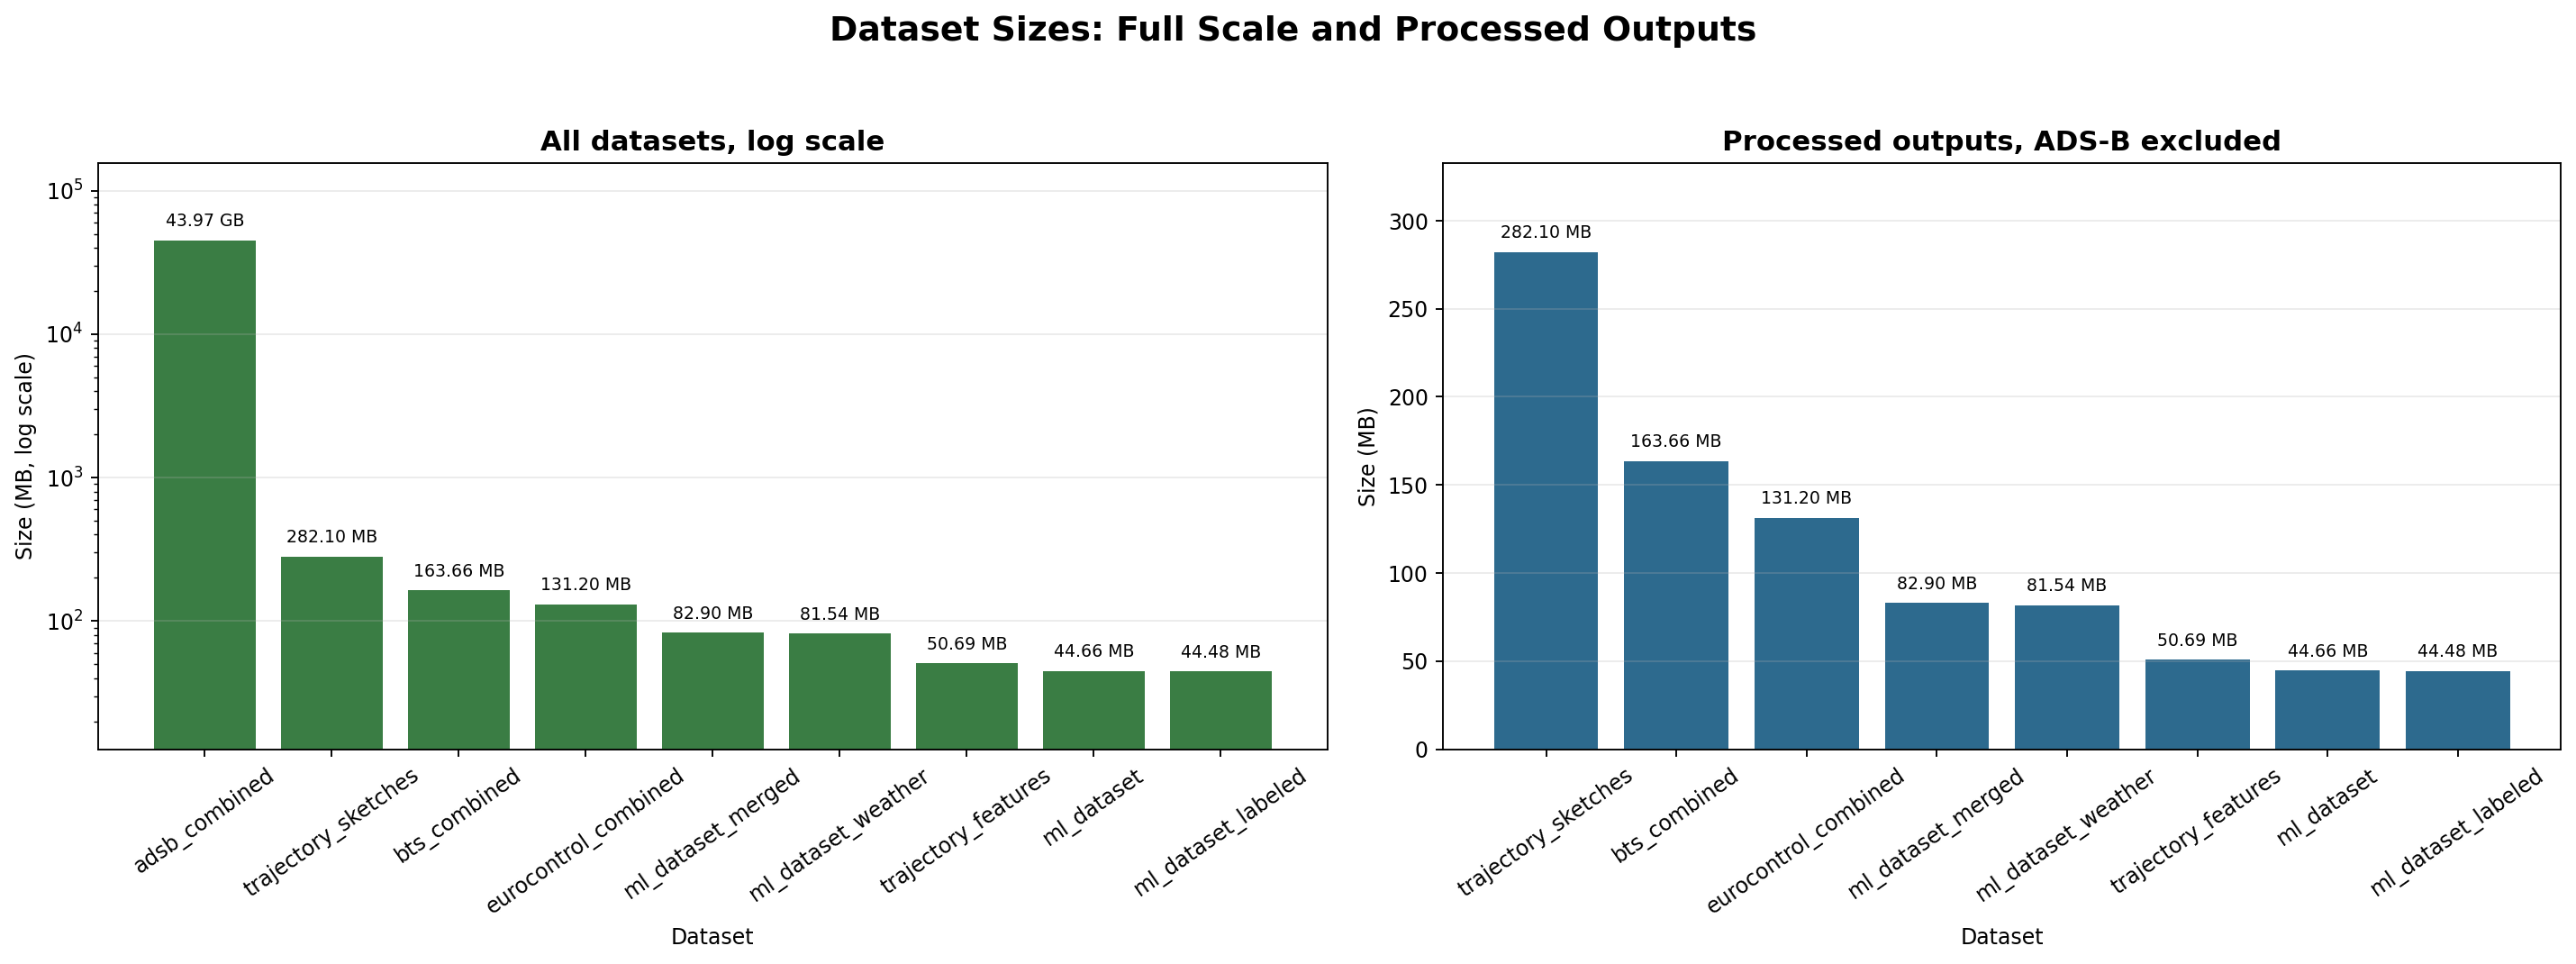


trajectory_quality_distribution.png


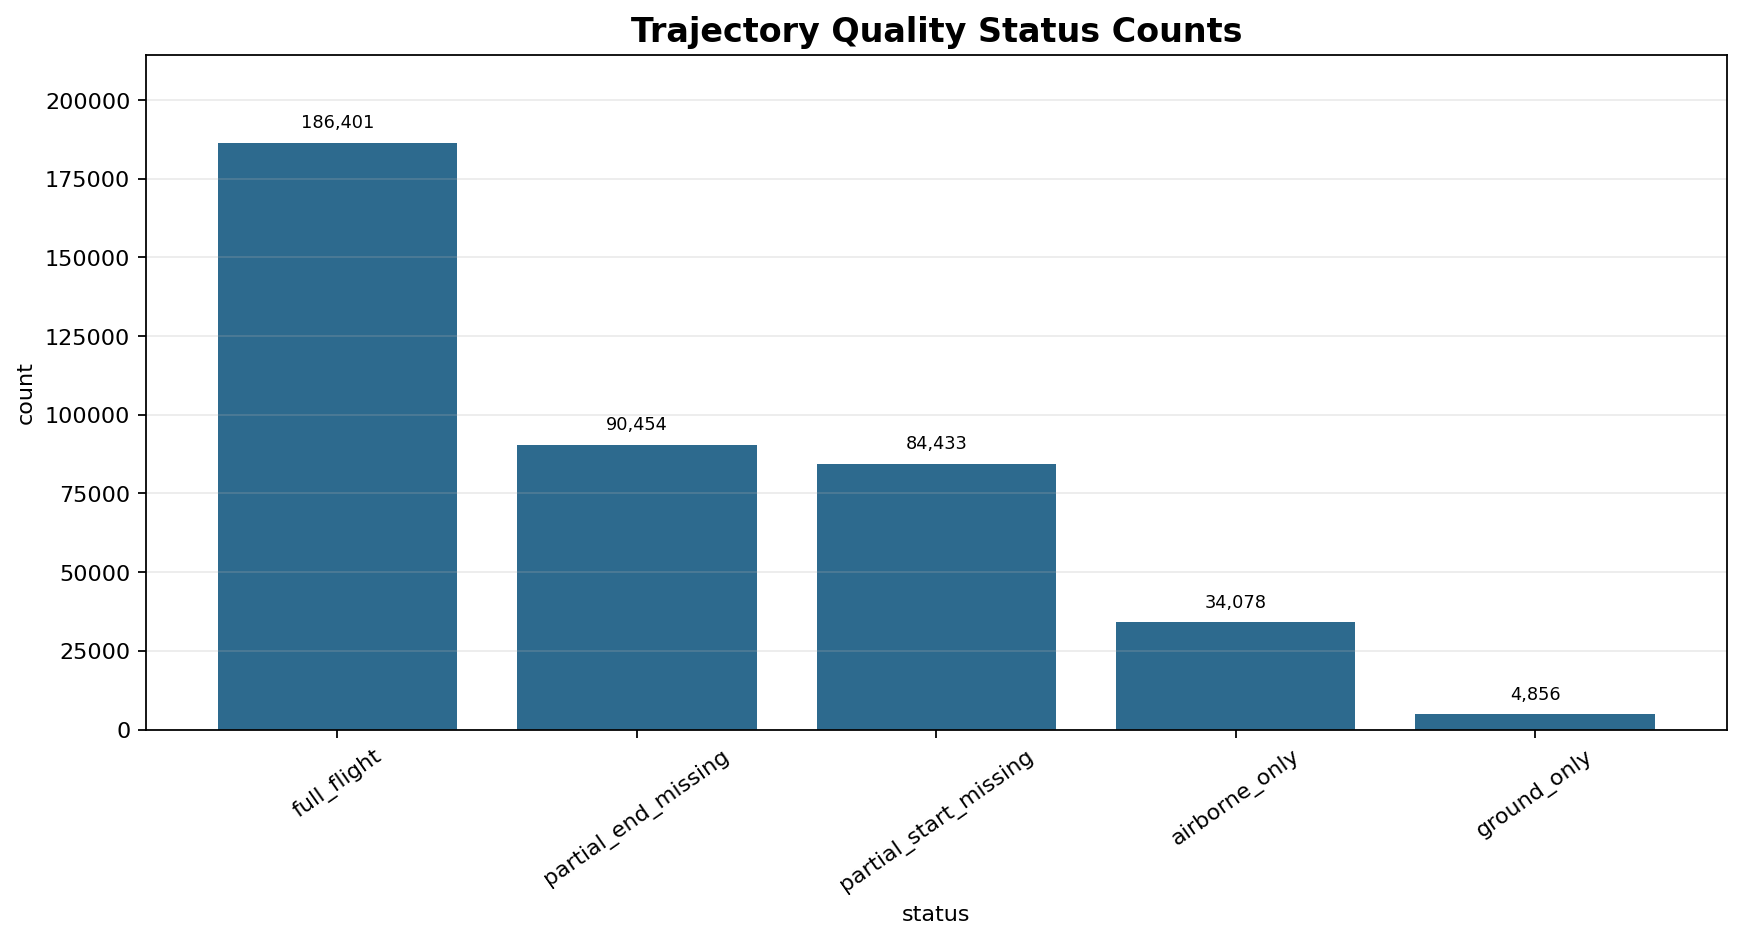


label_distribution.png


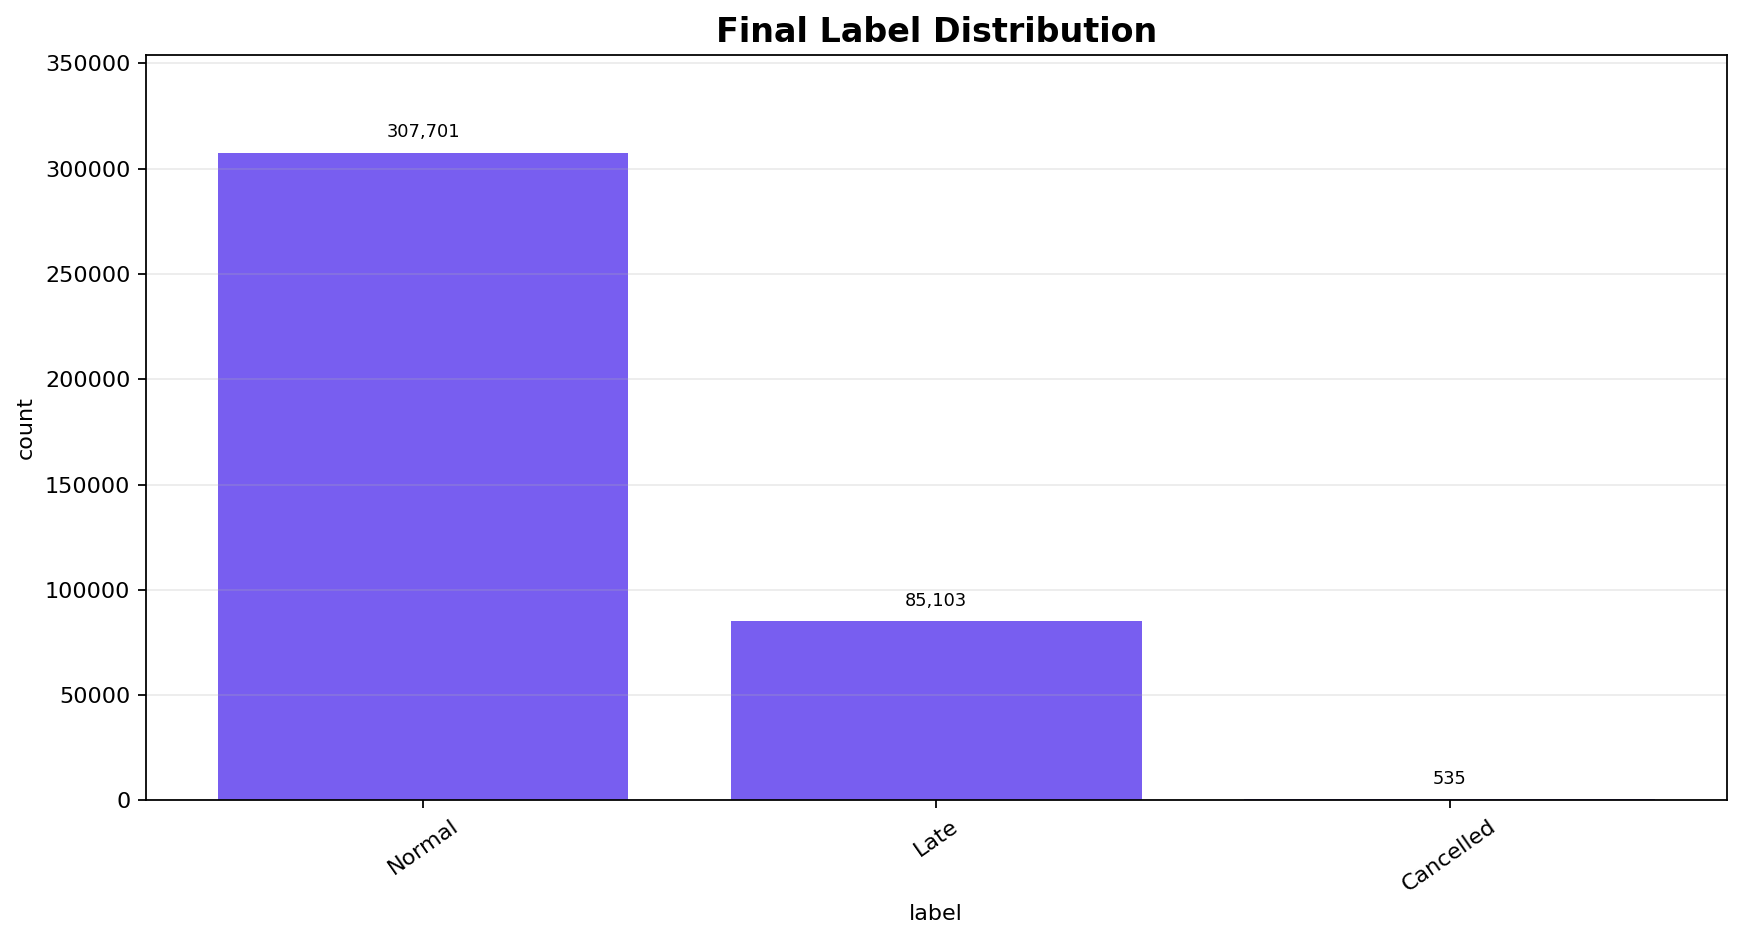


monthly_final_flight_counts.png


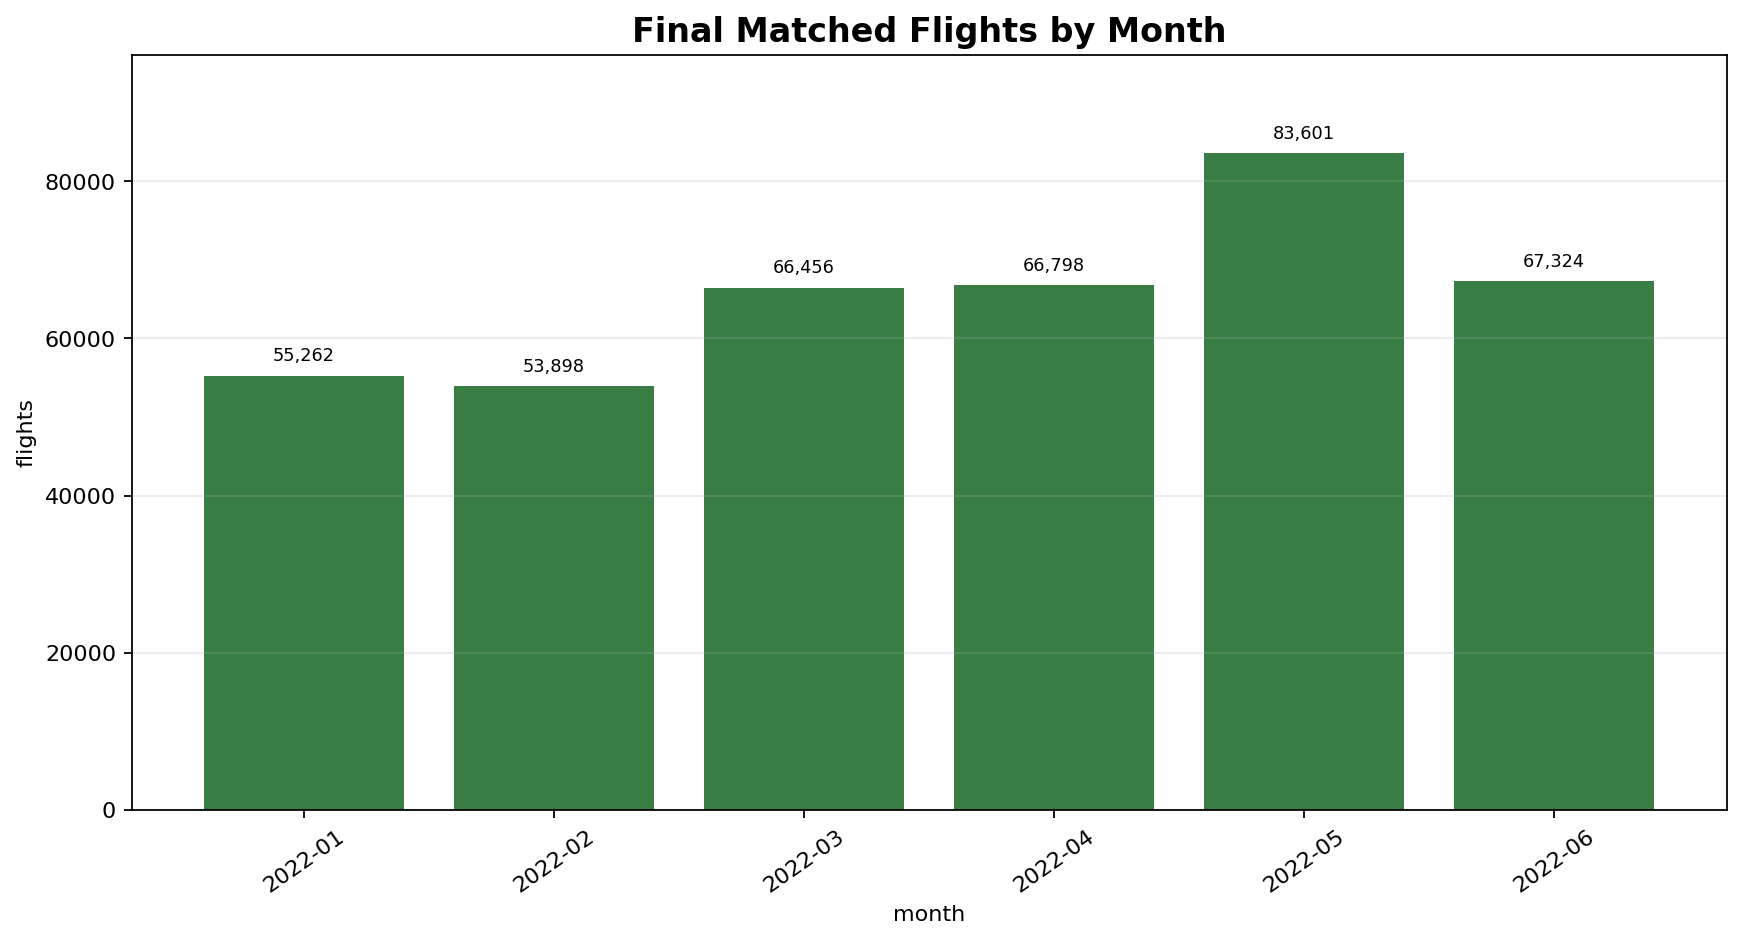


weather_coverage.png


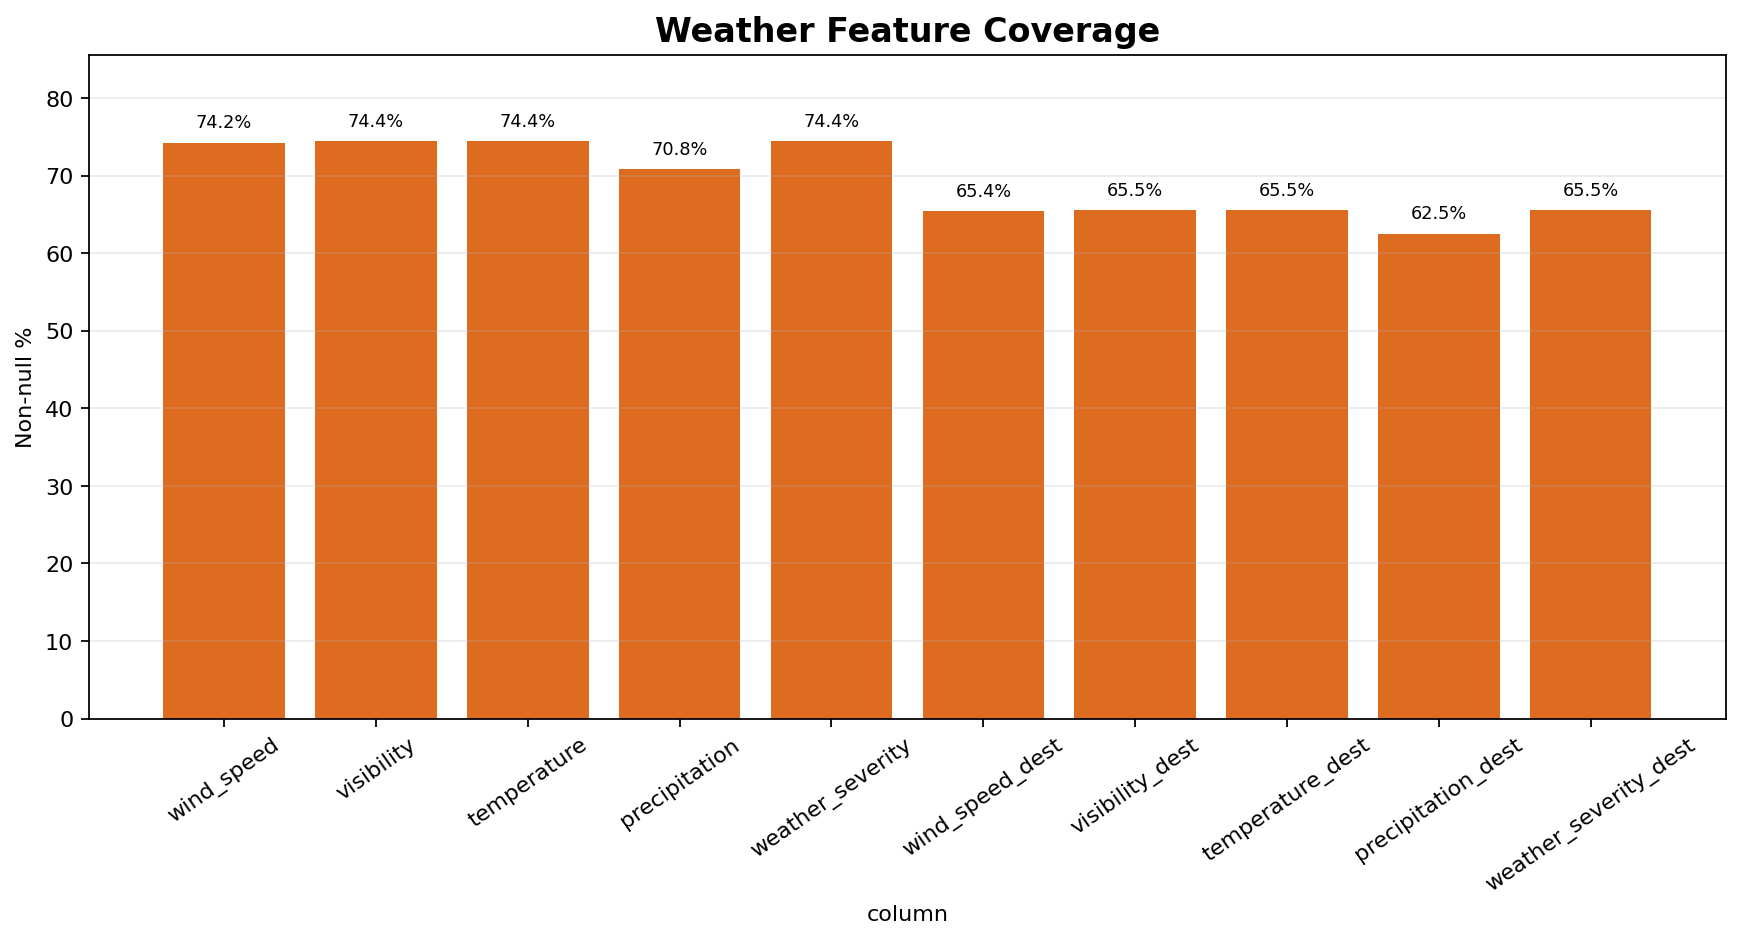


model_macro_f1.png


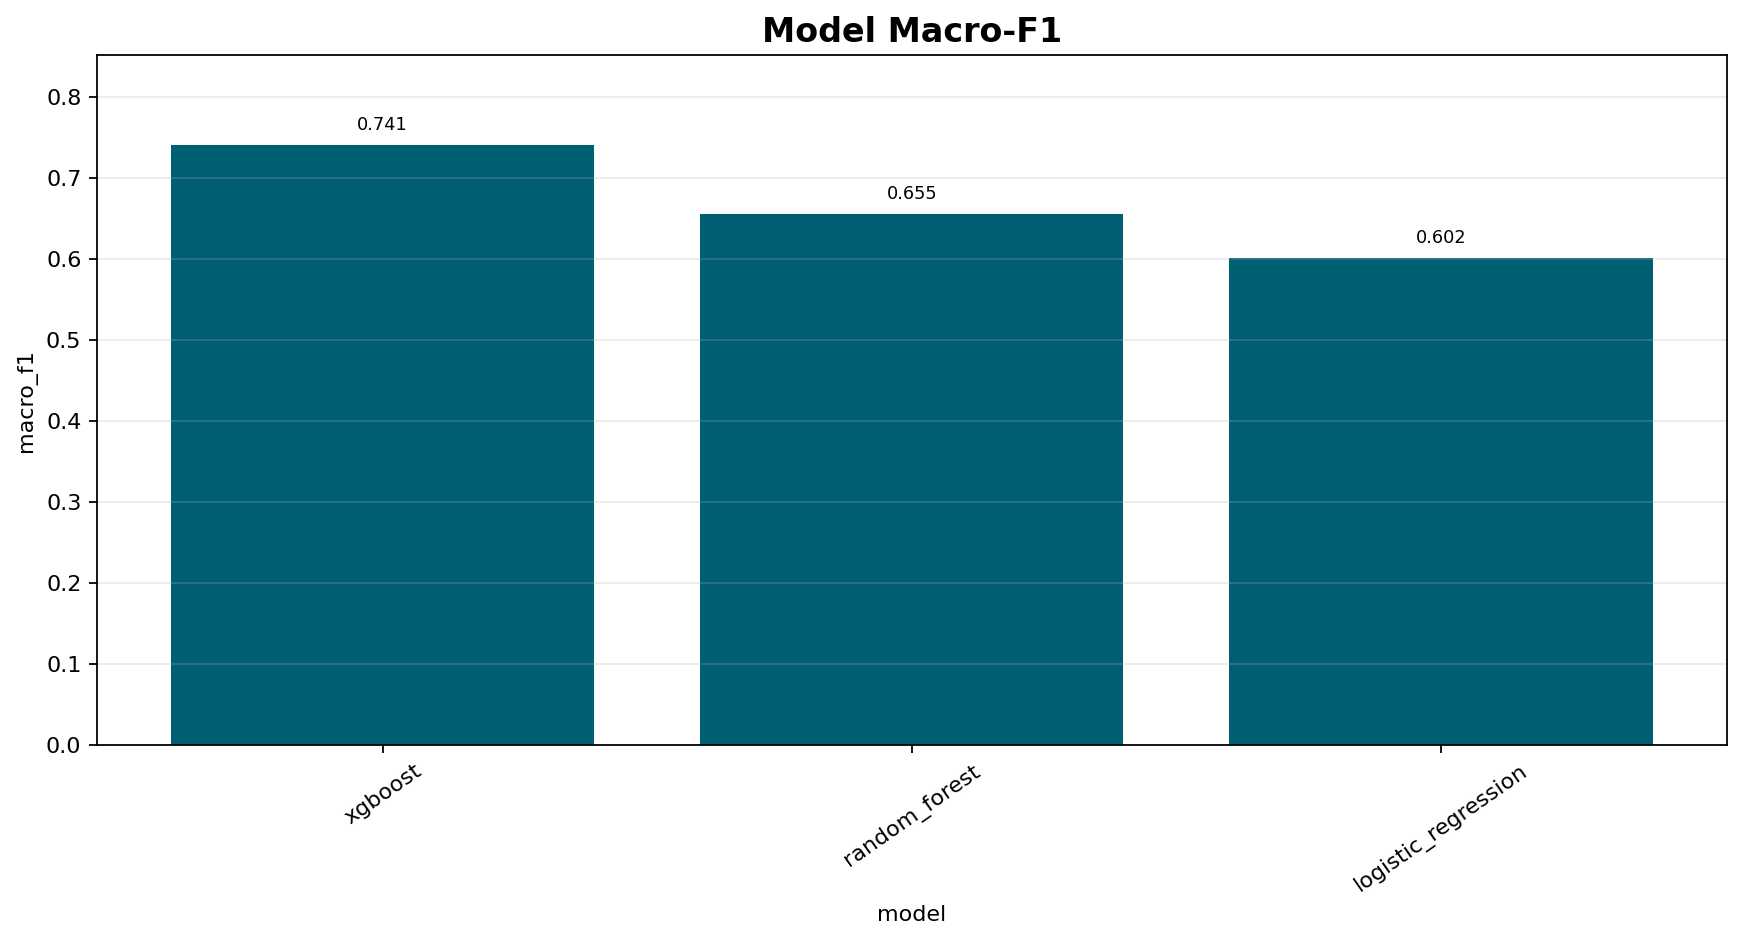


top_feature_importance.png


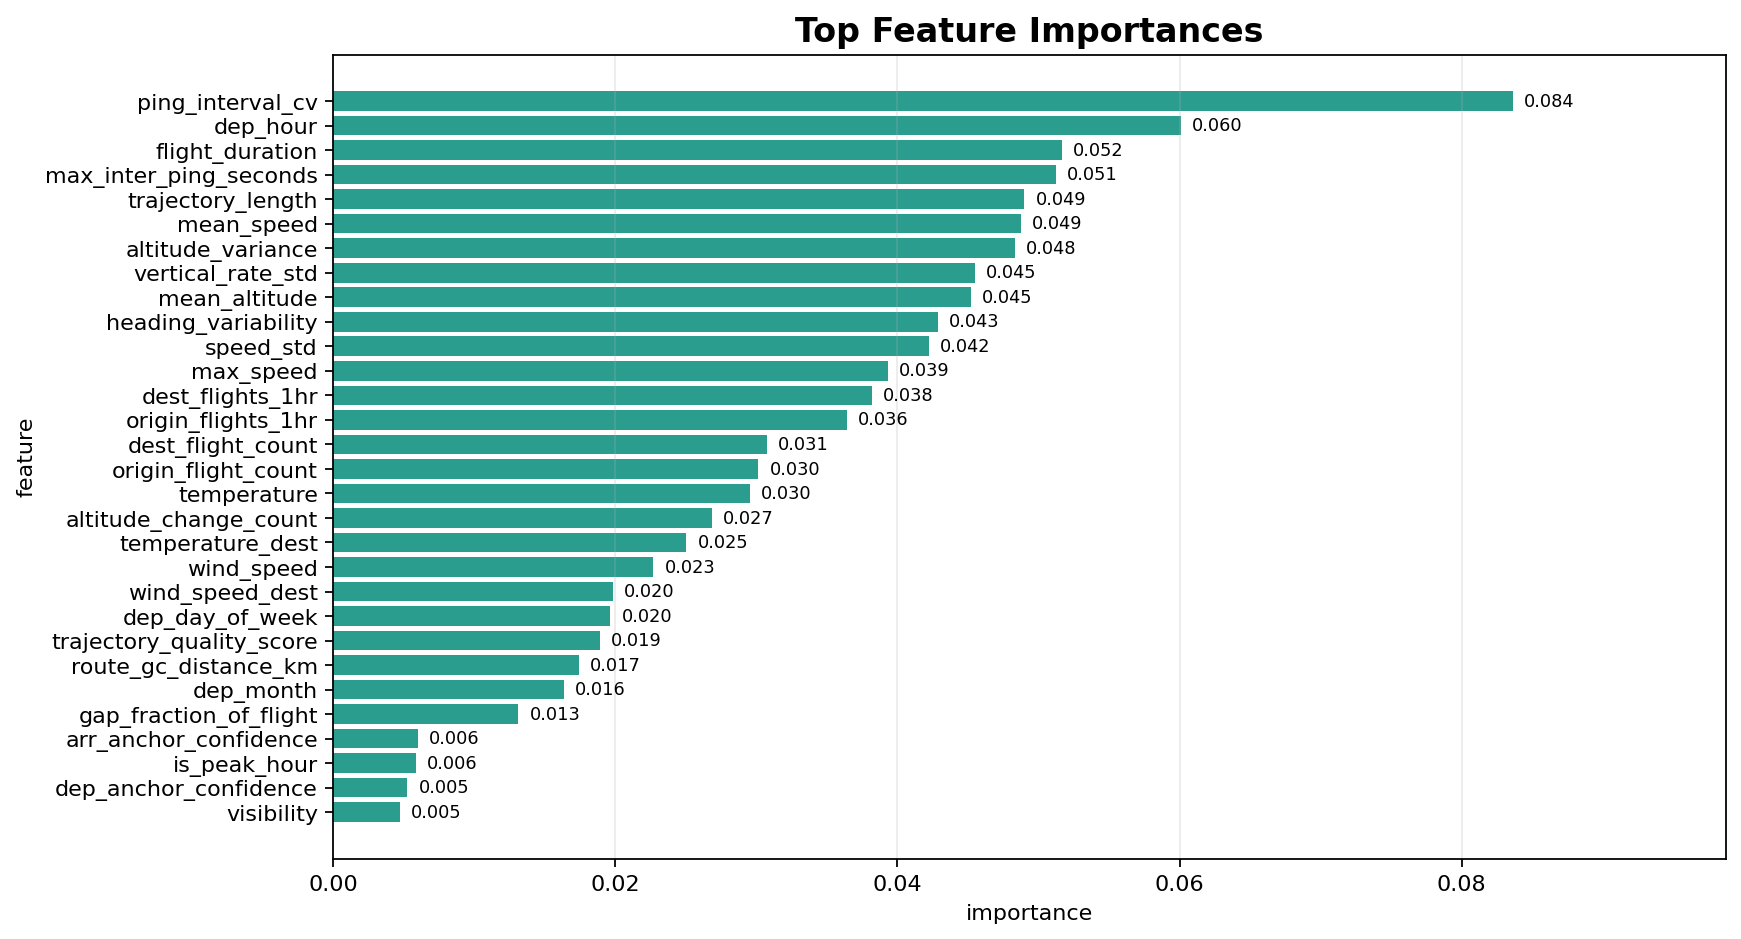

In [6]:
for image_name in [
    'pipeline_data_flow.png',
    'dataset_inventory.png',
    'dataset_sizes.png',
    'trajectory_quality_distribution.png',
    'label_distribution.png',
    'monthly_final_flight_counts.png',
    'weather_coverage.png',
    'model_macro_f1.png',
    'top_feature_importance.png',
]:
    image_path = report_dir / image_name
    if image_path.exists():
        print('\n' + image_name)
        display(Image(filename=str(image_path)))
    else:
        print('Missing:', image_name)